# Ablación de nodo — bloques y cabezas (2026-08-22)

**Objetivo:** bloque B del capítulo (circuit study), punto **B.4** de `CLAUDE.md`: *"apagar (o neutralizar) un head a la vez y medir el impacto en el desempeño — importancia causal individual"*, con la referencia de Michel, Levy & Neubig (2019) *"Are Sixteen Heads Really Better than One?"* y Voita et al. (2019) *"Analyzing Multi-Head Self-Attention"*.

No adivinamos qué bloque o cabeza "es mejor" apagar — los apagamos todos, uno a la vez, y medimos la caída de accuracy. Eso es literalmente lo que hace un experimento de ablación causal: en vez de intuir cuál capa importa más, se mide.

Dos niveles de granularidad:
1. **Ablación de bloque completo**: el bloque *i* se salta por completo (ni atención ni MLP) — el residual stream pasa sin tocar. Es la versión más gruesa ("layer drop").
2. **Ablación de cabeza individual**: dentro de un bloque, se apaga (pone en cero) la salida de una sola cabeza de atención antes de concatenar y proyectar — las demás cabezas de ese bloque y el resto del modelo siguen normales. Es la versión fina que pide B.4.

Con 4 bloques × 4 cabezas = 16 combinaciones, es barato correr todo el barrido.

Usamos el mismo checkpoint baseline que en `notebooks/17082026_logit_lens/` (`vit-with-15-epochs-CIFAR10`) para que los resultados sean comparables entre notebooks. El siguiente paso natural (ya para el capítulo real) es repetir esto con `vit-with-10-epochs-interpretable-CIFAR10` y comparar: la hipótesis de B.4 es que el baseline tiene cabezas prescindibles y otras críticas, mientras que el modelo penalizado reparte la importancia de forma más uniforme entre cabezas.

In [2]:
import json
import sys
from pathlib import Path

# Misma convención que el resto de notebooks/: vive 2 niveles bajo la raíz del proyecto.
project_root = Path.cwd().resolve().parents[1]
print(f"Project root: {project_root}")
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision

from modules.model import ViTForClassfication
from modules.datasets import CIFAR10Dataset

torch.manual_seed(0)

Project root: /Users/valefeve/Projects/interpretability of neural networks/interpretable-transformers


## 1. Cargar el modelo baseline

Mismo checkpoint que en el notebook de logit lens: `vit-with-15-epochs-CIFAR10` (~60% accuracy, sin penalización de similitud entre cabezas). `map_location="cpu"` porque el checkpoint se guardó desde MPS.

La ablación por cabeza que armamos abajo asume `use_faster_attention=False` (cabezas como submódulos separados, `block.attention.heads[i]`) — es el caso de todos los checkpoints guardados hasta ahora, pero lo verificamos con un `assert` para no fallar en silencio si algún día cambia.

In [15]:
EXPERIMENT_NAME = "vit-with-15-epochs-interpretable-CIFAR10"
exp_dir = project_root / "experimentation" / "experiments" / EXPERIMENT_NAME

with open(exp_dir / "config.json") as f:
    config = json.load(f)
with open(exp_dir / "metrics.json") as f:
    metrics = json.load(f)

assert not config["use_faster_attention"], (
    "Este notebook asume block.attention.heads (cabezas separadas); "
    "con use_faster_attention=True habria que adaptar la ablacion por cabeza."
)

model = ViTForClassfication(config)
state_dict = torch.load(exp_dir / "model_final.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()

n_blocks = len(model.encoder.blocks)
n_heads = config["num_attention_heads"]
print(f"Checkpoint: {EXPERIMENT_NAME}  (accuracy de entrenamiento: {metrics['accuracy']:.4f})")
print(f"Bloques: {n_blocks}  |  cabezas por bloque: {n_heads}")

Checkpoint: vit-with-15-epochs-interpretable-CIFAR10  (accuracy de entrenamiento: 0.5545)
Bloques: 4  |  cabezas por bloque: 4


## 2. Datos de test (CIFAR-10)

Mismo patrón que en `logit_lens.ipynb`: apuntamos a `experimentation/data`, donde ya está descargado CIFAR-10 (evita volver a descargar ~170MB).

In [16]:
dataset = CIFAR10Dataset()
dataset.testset = torchvision.datasets.CIFAR10(
    root=str(project_root / "experimentation" / "data"),
    train=False,
    download=True,
    transform=dataset.test_transform,
)
classes = dataset.classes

N_EVAL = 500  # tamano del lote de evaluacion (CPU-friendly)
eval_images, eval_labels = dataset.get_samples_from_indices(range(N_EVAL), device="cpu", set="test")
print(f"Lote de evaluacion: {N_EVAL} imagenes de test")

Lote de evaluacion: 500 imagenes de test


## 3. Funciones de ablación

`forward_with_block_skipped`: reimplementa el forward manualmente, saltando por completo un bloque cuando `skip_block_idx` coincide (el residual stream no se toca ese paso).

`forward_with_head_ablated`: igual, pero en el bloque `ablate_layer_idx` reconstruye la atención a mano — corre cada cabeza por separado (como hace `MultiHeadAttention.forward` internamente) y pone en cero la salida de `ablate_head_idx` antes de concatenar y proyectar. El resto del bloque (las otras cabezas, el MLP) sigue intacto.

Con `skip_block_idx=None` / `ablate_layer_idx=None` ninguna de las dos toca nada — deben reproducir exactamente el forward normal del modelo. Lo verificamos abajo antes de confiar en el resto del notebook.

In [17]:
@torch.no_grad()
def forward_with_block_skipped(model, x, skip_block_idx=None):
    h = model.embedding(x)
    for i, block in enumerate(model.encoder.blocks):
        if i == skip_block_idx:
            continue  # bloque completo salteado: el residual stream pasa sin tocar
        h, _ = block(h, output_attentions=False)
    return model.classifier(h[:, 0, :])


@torch.no_grad()
def forward_with_head_ablated(model, x, ablate_layer_idx=None, ablate_head_idx=None):
    h = model.embedding(x)
    for i, block in enumerate(model.encoder.blocks):
        if i == ablate_layer_idx:
            attn_in = block.layernorm_1(h)
            head_outputs = []
            for hidx, head in enumerate(block.attention.heads):
                out, _ = head(attn_in)
                if hidx == ablate_head_idx:
                    out = torch.zeros_like(out)
                head_outputs.append(out)
            concat = torch.cat(head_outputs, dim=-1)
            attn_out = block.attention.output_projection(concat)
            attn_out = block.attention.output_dropout(attn_out)
            h = h + attn_out
            mlp_out = block.mlp(block.layernorm_2(h))
            h = h + mlp_out
        else:
            h, _ = block(h, output_attentions=False)
    return model.classifier(h[:, 0, :])


@torch.no_grad()
def accuracy_of(logits, labels):
    return (logits.argmax(dim=-1) == labels).float().mean().item()

In [18]:
# Sanity check: sin ablacion, ambas funciones deben coincidir EXACTAMENTE
# con el forward normal del modelo.
with torch.no_grad():
    direct_logits, _ = model(eval_images, output_attentions=False)

block_fn_logits = forward_with_block_skipped(model, eval_images, skip_block_idx=None)
head_fn_logits = forward_with_head_ablated(model, eval_images, ablate_layer_idx=None, ablate_head_idx=None)

diff_block = (direct_logits - block_fn_logits).abs().max().item()
diff_head = (direct_logits - head_fn_logits).abs().max().item()
print(f"Diferencia maxima (forward_with_block_skipped, sin skip):  {diff_block:.2e}")
print(f"Diferencia maxima (forward_with_head_ablated, sin ablar):  {diff_head:.2e}")
assert diff_block < 1e-5 and diff_head < 1e-5, "Sin ablacion, ambas funciones deben reproducir el forward normal"

baseline_accuracy = accuracy_of(direct_logits, eval_labels)
print(f"\nAccuracy baseline (sin ablacion, n={N_EVAL}): {baseline_accuracy:.3f}")
print("OK - las reimplementaciones manuales son fieles al forward original.")

Diferencia maxima (forward_with_block_skipped, sin skip):  0.00e+00
Diferencia maxima (forward_with_head_ablated, sin ablar):  0.00e+00

Accuracy baseline (sin ablacion, n=500): 0.534
OK - las reimplementaciones manuales son fieles al forward original.


## 4. Ablación de bloque completo

Un bloque a la vez, saltado por completo. Si la accuracy cae poco al saltar un bloque, ese bloque es prescindible (su función la puede estar cubriendo el resto de la red); si cae mucho, es un bloque crítico.

skip block 1: accuracy = 0.452  (caida vs baseline: +0.082)
skip block 2: accuracy = 0.462  (caida vs baseline: +0.072)
skip block 3: accuracy = 0.452  (caida vs baseline: +0.082)
skip block 4: accuracy = 0.450  (caida vs baseline: +0.084)


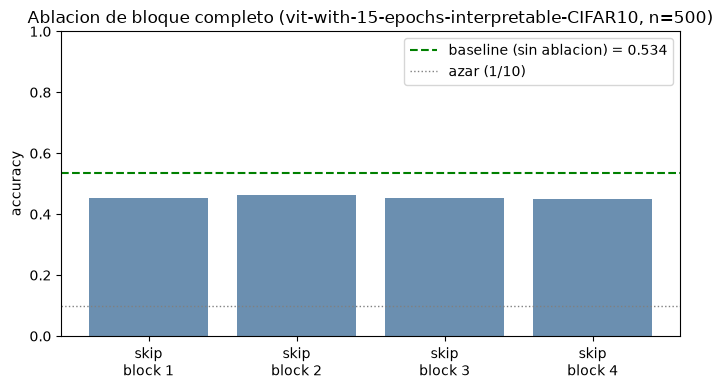


Bloque mas critico (mayor caida al saltarlo): block 4


In [19]:
block_accuracies = []
for i in range(n_blocks):
    logits = forward_with_block_skipped(model, eval_images, skip_block_idx=i)
    acc = accuracy_of(logits, eval_labels)
    block_accuracies.append(acc)
    print(f"skip block {i+1}: accuracy = {acc:.3f}  (caida vs baseline: {baseline_accuracy - acc:+.3f})")

fig, ax = plt.subplots(figsize=(7, 4))
labels_x = [f"skip\nblock {i+1}" for i in range(n_blocks)]
bars = ax.bar(labels_x, block_accuracies, color="#6b8fb0")
ax.axhline(baseline_accuracy, color="green", linestyle="--", linewidth=1.5, label=f"baseline (sin ablacion) = {baseline_accuracy:.3f}")
ax.axhline(1 / len(classes), color="gray", linestyle=":", linewidth=1, label="azar (1/10)")
ax.set_ylabel("accuracy")
ax.set_title(f"Ablacion de bloque completo ({EXPERIMENT_NAME}, n={N_EVAL})")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

most_critical_block = int(np.argmin(block_accuracies))
print(f"\nBloque mas critico (mayor caida al saltarlo): block {most_critical_block + 1}")

## 5. Ablación de cabeza individual

Las 4×4 combinaciones de (bloque, cabeza), cada una apagada por separado. El resultado clásico de este tipo de análisis (Michel et al. 2019, Voita et al. 2019) es que unas pocas cabezas concentran casi toda la importancia y muchas otras son casi redundantes — eso es justo lo que la hipótesis de B.4 quiere contrastar entre baseline y penalizado.

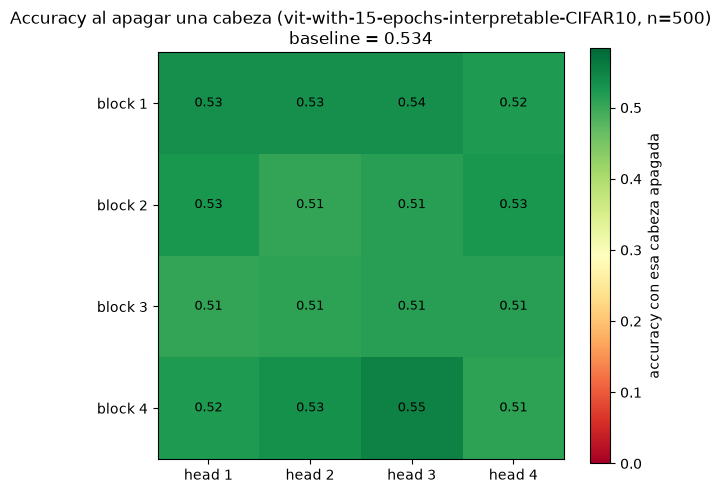

Ranking de cabezas por caida de accuracy al apagarlas (mas critica primero):
  block 2, head 2: caida = +0.028  (accuracy = 0.506)
  block 3, head 1: caida = +0.028  (accuracy = 0.506)
  block 3, head 2: caida = +0.024  (accuracy = 0.510)
  block 4, head 4: caida = +0.024  (accuracy = 0.510)
  block 2, head 3: caida = +0.020  (accuracy = 0.514)
  block 3, head 3: caida = +0.020  (accuracy = 0.514)
  block 3, head 4: caida = +0.020  (accuracy = 0.514)
  block 1, head 4: caida = +0.012  (accuracy = 0.522)
  block 4, head 1: caida = +0.012  (accuracy = 0.522)
  block 2, head 1: caida = +0.008  (accuracy = 0.526)
  block 2, head 4: caida = +0.008  (accuracy = 0.526)
  block 4, head 2: caida = +0.002  (accuracy = 0.532)
  block 1, head 1: caida = +0.000  (accuracy = 0.534)
  block 1, head 2: caida = +0.000  (accuracy = 0.534)
  block 1, head 3: caida = -0.002  (accuracy = 0.536)
  block 4, head 3: caida = -0.016  (accuracy = 0.550)


In [9]:
head_accuracy = np.zeros((n_blocks, n_heads))
for layer_idx in range(n_blocks):
    for head_idx in range(n_heads):
        logits = forward_with_head_ablated(model, eval_images, ablate_layer_idx=layer_idx, ablate_head_idx=head_idx)
        head_accuracy[layer_idx, head_idx] = accuracy_of(logits, eval_labels)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(head_accuracy, cmap="RdYlGn", vmin=0, vmax=baseline_accuracy + 0.05)
ax.set_xticks(range(n_heads))
ax.set_xticklabels([f"head {h+1}" for h in range(n_heads)])
ax.set_yticks(range(n_blocks))
ax.set_yticklabels([f"block {l+1}" for l in range(n_blocks)])
for l in range(n_blocks):
    for h in range(n_heads):
        ax.text(h, l, f"{head_accuracy[l, h]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title(f"Accuracy al apagar una cabeza ({EXPERIMENT_NAME}, n={N_EVAL})\nbaseline = {baseline_accuracy:.3f}")
fig.colorbar(im, ax=ax, label="accuracy con esa cabeza apagada")
plt.tight_layout()
plt.show()

# Ranking de mas a menos critica (mayor caida primero)
drops = baseline_accuracy - head_accuracy
ranking = sorted(
    [(l, h, drops[l, h]) for l in range(n_blocks) for h in range(n_heads)],
    key=lambda t: -t[2],
)
print("Ranking de cabezas por caida de accuracy al apagarlas (mas critica primero):")
for l, h, d in ranking:
    print(f"  block {l+1}, head {h+1}: caida = {d:+.3f}  (accuracy = {head_accuracy[l, h]:.3f})")

## Para reflexionar / siguientes pasos

- ¿Hay cabezas casi prescindibles (accuracy prácticamente igual al baseline) y otras claramente críticas? ¿En qué bloque(s) se concentran las críticas?
- ¿El bloque más crítico a nivel completo (sección 4) coincide con el bloque que tiene la cabeza más crítica (sección 5), o son distintos? (una cabeza puede ser crítica sin que su bloque entero lo sea, si las otras cabezas del mismo bloque compensan parcialmente)
- Con `N_EVAL=500` el ranking ya debería ser bastante estable, pero vale la pena subirlo antes de citar números exactos en la tesis.

**Siguiente paso real (B.4 del capítulo):** repetir esta misma ablación (bloque y cabeza) sobre `vit-with-10-epochs-interpretable-CIFAR10` y comparar los dos heatmaps lado a lado — la hipótesis a contrastar es que el penalizado reparte la importancia de forma más uniforme (heatmap más "plano") que el baseline (heatmap con pocas cabezas dominantes). Complemento barato para después: contribución directa al logit por cabeza (proyectar la salida de cada cabeza, ya multiplicada por su parte de `output_projection`, directo al espacio de logits) — más rápido que la ablación porque no requiere volver a correr el forward, pero asume que no hay demasiada interacción no lineal aguas abajo.